<h1>Netflix Churn Prediction</h1>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<h1>Load dataset</h1>

In [2]:
df = pd.read_csv("dataset/netflix_users.csv")

<h1>Explore dataset</h1>

<h3>Basic Inspection</h3>

In [3]:
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14


In [4]:
df.shape

(25000, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   User_ID            25000 non-null  int64  
 1   Name               25000 non-null  str    
 2   Age                25000 non-null  int64  
 3   Country            25000 non-null  str    
 4   Subscription_Type  25000 non-null  str    
 5   Watch_Time_Hours   25000 non-null  float64
 6   Favorite_Genre     25000 non-null  str    
 7   Last_Login         25000 non-null  str    
dtypes: float64(1), int64(2), str(5)
memory usage: 1.5 MB


In [6]:
df.columns

Index(['User_ID', 'Name', 'Age', 'Country', 'Subscription_Type',
       'Watch_Time_Hours', 'Favorite_Genre', 'Last_Login'],
      dtype='str')

In [7]:
df.isnull().sum()

User_ID              0
Name                 0
Age                  0
Country              0
Subscription_Type    0
Watch_Time_Hours     0
Favorite_Genre       0
Last_Login           0
dtype: int64

In [8]:
df.describe()

,User_ID,Age,Watch_Time_Hours
count,25000.000000,25000.000000,25000.000000
mean,12500.500000,46.482880,500.468858
std,7217.022701,19.594861,286.381815
min,1.000000,13.000000,0.120000
25%,6250.750000,29.000000,256.567500
50%,12500.500000,46.000000,501.505000
75%,18750.250000,63.000000,745.732500
max,25000.000000,80.000000,999.990000


In [9]:
df.describe(include="all")

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login
count,25000.000000,25000,25000.000000,25000,25000,25000.000000,25000,25000
unique,NaN,100,NaN,10,3,NaN,7,366
top,NaN,Michael Hernandez,NaN,UK,Premium,NaN,Horror,2024-09-05
freq,NaN,292,NaN,2592,8402,NaN,3654,92
mean,12500.500000,NaN,46.482880,NaN,NaN,500.468858,NaN,NaN
std,7217.022701,NaN,19.594861,NaN,NaN,286.381815,NaN,NaN
min,1.000000,NaN,13.000000,NaN,NaN,0.120000,NaN,NaN
25%,6250.750000,NaN,29.000000,NaN,NaN,256.567500,NaN,NaN
50%,12500.500000,NaN,46.000000,NaN,NaN,501.505000,NaN,NaN
75%,18750.250000,NaN,63.000000,NaN,NaN,745.732500,NaN,NaN


In [10]:
df.duplicated().sum()

np.int64(0)

<h3>Understanding categorical columns</h3>

In [11]:
df['Subscription_Type'].unique()

<StringArray>
['Premium', 'Basic', 'Standard']
Length: 3, dtype: str

In [12]:
df['Country'].unique()

<StringArray>
[   'France',       'USA',        'UK',    'Canada',    'Mexico',     'Japan',
 'Australia',   'Germany',    'Brazil',     'India']
Length: 10, dtype: str

In [13]:
df['Favorite_Genre'].unique()

<StringArray>
['Drama', 'Sci-Fi', 'Comedy', 'Documentary', 'Romance', 'Action', 'Horror']
Length: 7, dtype: str

In [14]:
df['Subscription_Type'].value_counts()

Subscription_Type
Premium     8402
Basic       8356
Standard    8242
Name: count, dtype: int64

In [15]:
df['Country'].value_counts()

Country
UK           2592
Germany      2547
India        2505
USA          2503
Brazil       2503
Mexico       2493
Canada       2490
France       2473
Japan        2457
Australia    2437
Name: count, dtype: int64

In [16]:
df['Favorite_Genre'].value_counts()

Favorite_Genre
Horror         3654
Documentary    3636
Action         3589
Romance        3572
Comedy         3561
Drama          3533
Sci-Fi         3455
Name: count, dtype: int64

<h3>Convert Date Column</h3>

In [18]:
df['Last_Login'].dtype

<StringDtype(storage='python', na_value=nan)>

In [19]:
df['Last_Login'] = pd.to_datetime(df['Last_Login'])

In [20]:
df['Last_Login'].dtype

dtype('<M8[us]')

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   User_ID                25000 non-null  int64         
 1   Name                   25000 non-null  str           
 2   Age                    25000 non-null  int64         
 3   Country                25000 non-null  str           
 4   Subscription_Type      25000 non-null  str           
 5   Watch_Time_Hours       25000 non-null  float64       
 6   Favorite_Genre         25000 non-null  str           
 7   Last_Login             25000 non-null  datetime64[us]
 8   Days_Since_Last_Login  25000 non-null  int64         
dtypes: datetime64[us](1), float64(1), int64(3), str(4)
memory usage: 1.7 MB


<h4>Get Reference Date</h4>

In [21]:
df['Last_Login'].max()

Timestamp('2025-03-08 00:00:00')

In [22]:
df['Last_Login'].min()

Timestamp('2024-03-08 00:00:00')

<h3>Converting the latest date to current_date</h3>

In [23]:
current_date = df['Last_Login'].max()

In [24]:
df['Days_Since_Last_Login'] = (current_date - df['Last_Login']).dt.days

In [25]:
df['Days_Since_Last_Login']

0        300
1         31
2         43
3        348
4         53
        ... 
24995     49
24996    252
24997    143
24998    193
24999    330
Name: Days_Since_Last_Login, Length: 25000, dtype: int64

In [26]:
df['Days_Since_Last_Login'].isna().sum()

np.int64(0)

In [27]:
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Since_Last_Login
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,300
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,31
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,43
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,348
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,53


In [28]:
df.tail()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Since_Last_Login
24995,24996,David Miller,18,Australia,Premium,183.88,Horror,2025-01-18,49
24996,24997,Jane Miller,17,USA,Premium,112.37,Drama,2024-06-29,252
24997,24998,Sarah Miller,14,USA,Premium,351.80,Action,2024-10-16,143
24998,24999,Michael Williams,71,USA,Basic,655.89,Action,2024-08-27,193
24999,25000,James Jones,19,Germany,Premium,207.06,Documentary,2024-04-12,330


<h2>Creating Churn Feature using Days_Since_Last_Login</h2>

<h4>Customers are said to be churned, iff days since last login is less than 120 days and watch time hours must be greater than 240, else not churned. Now let's make a new feature 'Churn'</h4>

In [32]:
df['Churn'] = ((df['Days_Since_Last_Login'] > 120) & (df['Watch_Time_Hours'] > 200)).astype(int)

In [33]:
df.head()

,User_ID,Name,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Last_Login,Days_Since_Last_Login,Churn
0,1,James Martinez,18,France,Premium,80.26,Drama,2024-05-12,300,0
1,2,John Miller,23,USA,Premium,321.75,Sci-Fi,2025-02-05,31,0
2,3,Emma Davis,60,UK,Basic,35.89,Comedy,2025-01-24,43,0
3,4,Emma Miller,44,USA,Premium,261.56,Documentary,2024-03-25,348,1
4,5,Jane Smith,68,USA,Standard,909.30,Drama,2025-01-14,53,0


In [34]:
df['Churn'].value_counts()

Churn
1    13380
0    11620
Name: count, dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

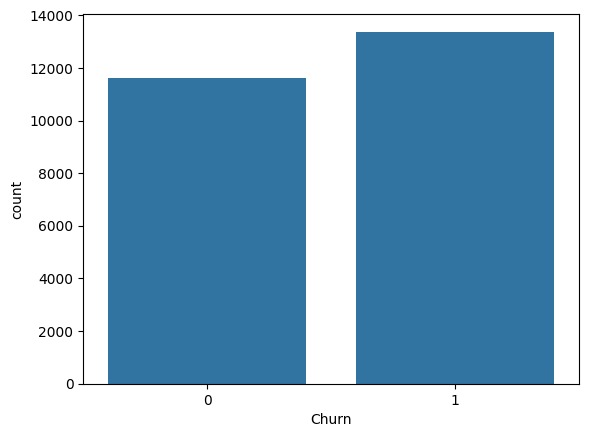

In [41]:
sns.countplot(x='Churn', data=df)

<h3>Removing unnecessary columns</h3>

<p>Here, User_ID, Name, Days_Since_Last_Login and Last_Login are not useful columns. So, let's remove them safely</p>

In [35]:
df1 = df.drop(['User_ID', 'Name', 'Last_Login', 'Days_Since_Last_Login'], axis=1)

In [36]:
df1.head()

,Age,Country,Subscription_Type,Watch_Time_Hours,Favorite_Genre,Churn
0,18,France,Premium,80.26,Drama,0
1,23,USA,Premium,321.75,Sci-Fi,0
2,60,UK,Basic,35.89,Comedy,0
3,44,USA,Premium,261.56,Documentary,1
4,68,USA,Standard,909.30,Drama,0


<h2>Exploratory Data Analysis (EDA)</h2>

<h4>Age vs Churn</h4>

In [38]:
df1['Age'].value_counts()

Age
26    407
40    406
45    405
57    404
62    400
     ... 
13    339
51    338
73    334
74    330
36    326
Name: count, Length: 68, dtype: int64

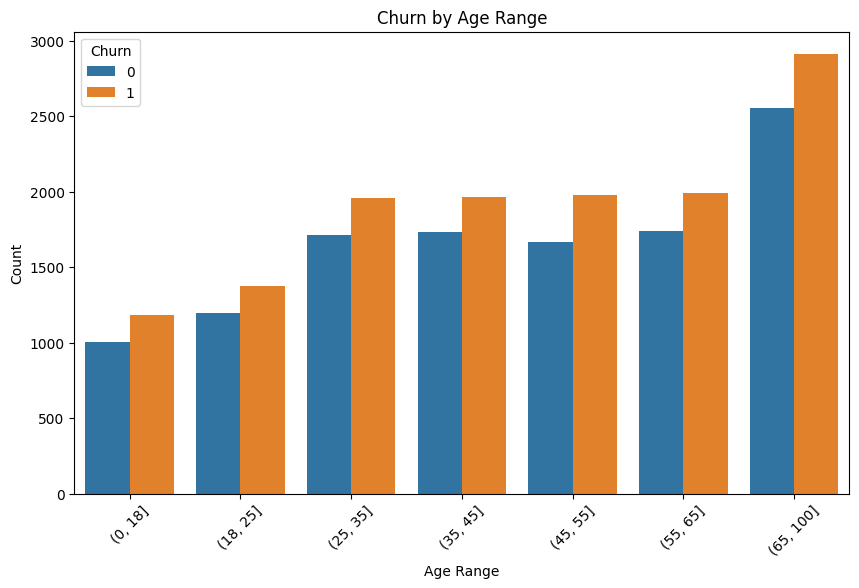

In [40]:
# Creating age ranges (bins)
bins = [0, 18, 25, 35, 45, 55, 65, 100]

plt.figure(figsize=(10,6))
sns.countplot(x=pd.cut(df1['Age'], bins=bins), hue=df1['Churn'])
plt.xlabel('Age Range')
plt.ylabel('Count')
plt.title('Churn by Age Range')
plt.xticks(rotation=45)
plt.show()

<h4>Country vs Churn</h4>

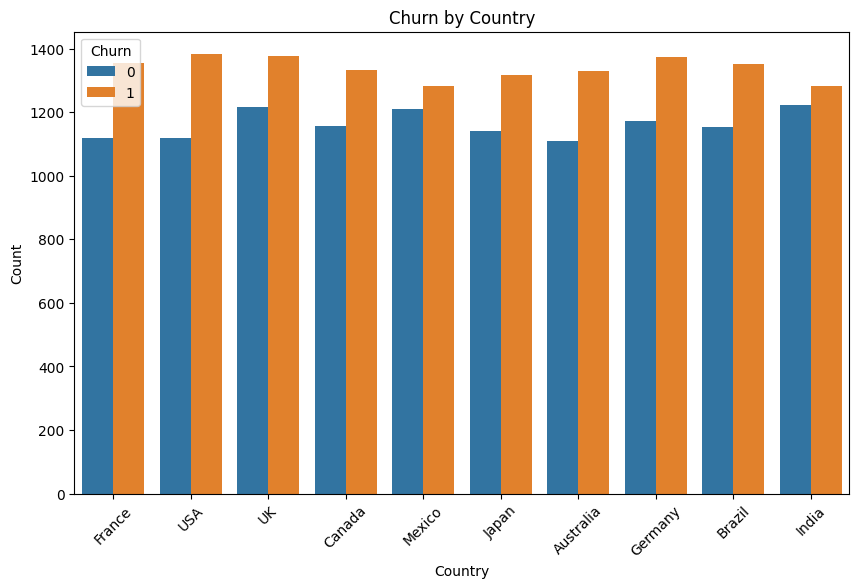

In [44]:
plt.figure(figsize=(10,6))
sns.countplot(x='Country', hue='Churn', data=df1)
plt.title('Churn by Country')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<h4>Subscription Type vs Churn</h4>

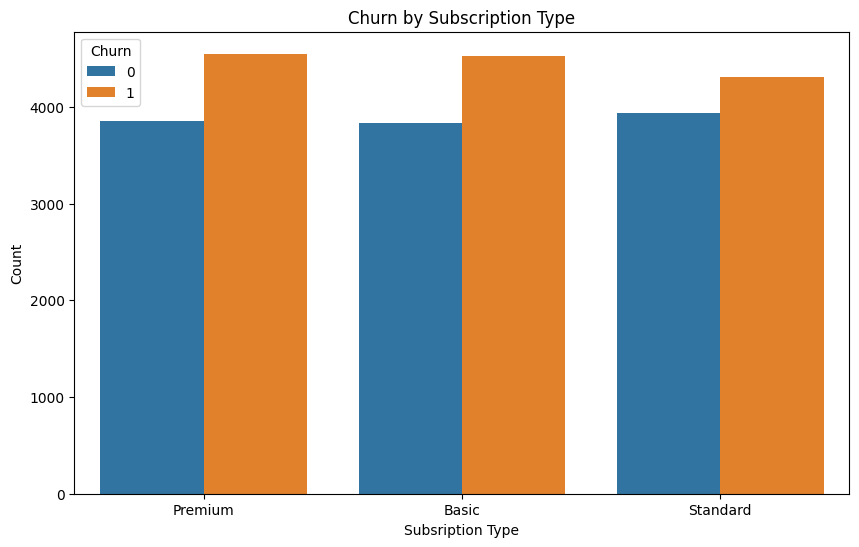

In [45]:
plt.figure(figsize=(10,6))
sns.countplot(x='Subscription_Type', hue='Churn', data=df1)
plt.title('Churn by Subscription Type')
plt.xlabel('Subsription Type')
plt.ylabel('Count')
plt.show()

<h4>Favorite Genre vs Churn</h4>

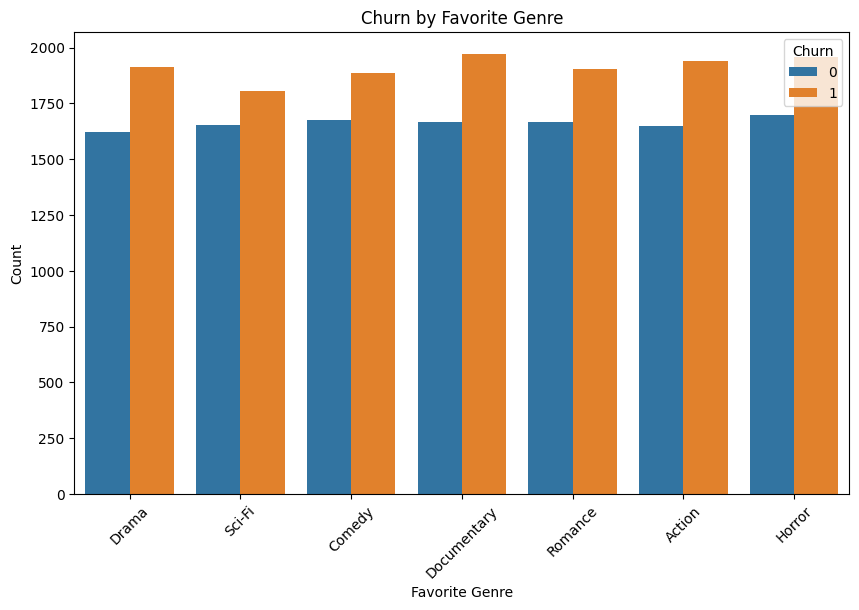

In [46]:
plt.figure(figsize=(10,6))
sns.countplot(x='Favorite_Genre', hue='Churn', data=df1)
plt.title('Churn by Favorite Genre')
plt.xlabel('Favorite Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

<h4>Watch Time Hours vs Churn</h4>

In [47]:
df1['Watch_Time_Hours'].value_counts()

Watch_Time_Hours
995.15    5
715.37    5
875.79    4
592.47    4
326.09    4
         ..
486.92    1
47.74     1
183.88    1
655.89    1
207.06    1
Name: count, Length: 22087, dtype: int64

In [48]:
df1['Watch_Time_Hours'].describe()

count    25000.000000
mean       500.468858
std        286.381815
min          0.120000
25%        256.567500
50%        501.505000
75%        745.732500
max        999.990000
Name: Watch_Time_Hours, dtype: float64

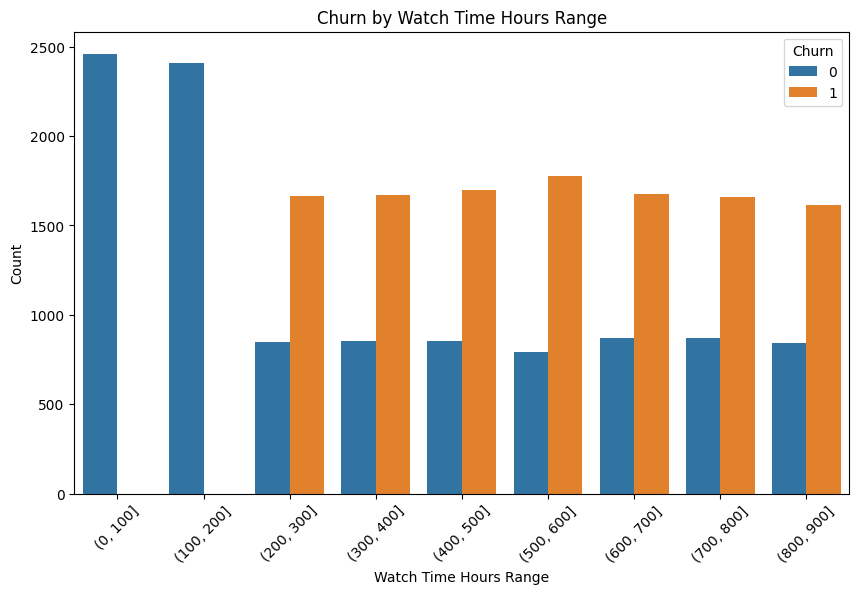

In [49]:
bins = [0, 100, 200, 300, 400, 500, 600, 700, 800, 900]

plt.figure(figsize=(10,6))
sns.countplot(x=pd.cut(df1['Watch_Time_Hours'], bins=bins), hue=df1['Churn'])
plt.xlabel('Watch Time Hours Range')
plt.ylabel('Count')
plt.title('Churn by Watch Time Hours Range')
plt.xticks(rotation=45)
plt.show()

<h3>Correlation Heatmap</h3>

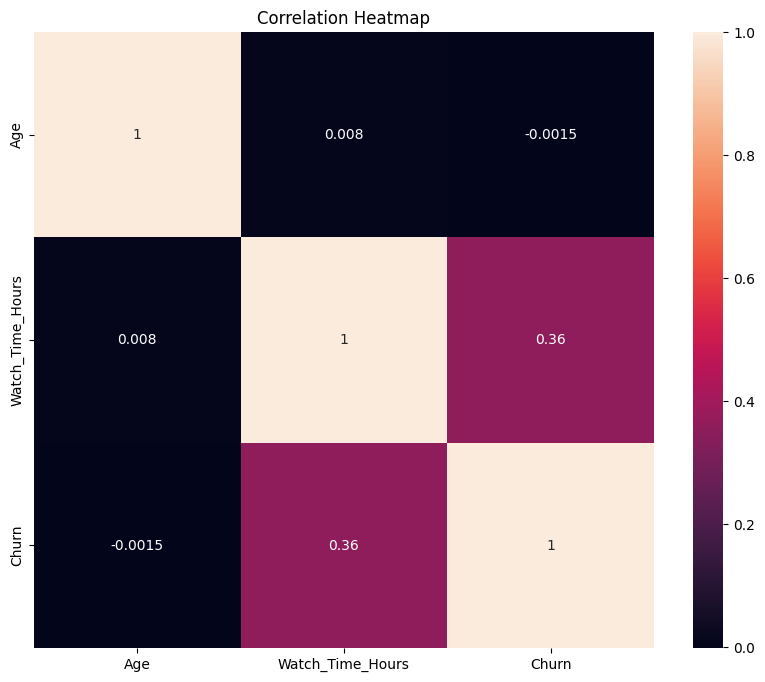

In [50]:
plt.figure(figsize=(10,8))
sns.heatmap(df1.corr(numeric_only=True), annot=True)
plt.title('Correlation Heatmap')
plt.show()

<h2>Categorical Encoding</h2>

In [51]:
df2 = pd.get_dummies(df1, drop_first=True, dtype=int)

In [52]:
df2.head()

,Age,Watch_Time_Hours,Churn,Country_Brazil,Country_Canada,Country_France,Country_Germany,Country_India,Country_Japan,Country_Mexico,Country_UK,Country_USA,Subscription_Type_Premium,Subscription_Type_Standard,Favorite_Genre_Comedy,Favorite_Genre_Documentary,Favorite_Genre_Drama,Favorite_Genre_Horror,Favorite_Genre_Romance,Favorite_Genre_Sci-Fi
0,18,80.26,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0
1,23,321.75,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,1
2,60,35.89,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0
3,44,261.56,1,0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0
4,68,909.30,0,0,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0


In [53]:
df2.columns

Index(['Age', 'Watch_Time_Hours', 'Churn', 'Country_Brazil', 'Country_Canada',
       'Country_France', 'Country_Germany', 'Country_India', 'Country_Japan',
       'Country_Mexico', 'Country_UK', 'Country_USA',
       'Subscription_Type_Premium', 'Subscription_Type_Standard',
       'Favorite_Genre_Comedy', 'Favorite_Genre_Documentary',
       'Favorite_Genre_Drama', 'Favorite_Genre_Horror',
       'Favorite_Genre_Romance', 'Favorite_Genre_Sci-Fi'],
      dtype='str')

In [54]:
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         25000 non-null  int64  
 1   Watch_Time_Hours            25000 non-null  float64
 2   Churn                       25000 non-null  int64  
 3   Country_Brazil              25000 non-null  int64  
 4   Country_Canada              25000 non-null  int64  
 5   Country_France              25000 non-null  int64  
 6   Country_Germany             25000 non-null  int64  
 7   Country_India               25000 non-null  int64  
 8   Country_Japan               25000 non-null  int64  
 9   Country_Mexico              25000 non-null  int64  
 10  Country_UK                  25000 non-null  int64  
 11  Country_USA                 25000 non-null  int64  
 12  Subscription_Type_Premium   25000 non-null  int64  
 13  Subscription_Type_Standard  25000 non-null

In [55]:
df2.shape

(25000, 20)

<h2>Feature Selection</h2>

In [56]:
# Feature and Target variable
X = df2.drop('Churn', axis=1)
y = df2['Churn']

In [59]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         25000 non-null  int64  
 1   Watch_Time_Hours            25000 non-null  float64
 2   Country_Brazil              25000 non-null  int64  
 3   Country_Canada              25000 non-null  int64  
 4   Country_France              25000 non-null  int64  
 5   Country_Germany             25000 non-null  int64  
 6   Country_India               25000 non-null  int64  
 7   Country_Japan               25000 non-null  int64  
 8   Country_Mexico              25000 non-null  int64  
 9   Country_UK                  25000 non-null  int64  
 10  Country_USA                 25000 non-null  int64  
 11  Subscription_Type_Premium   25000 non-null  int64  
 12  Subscription_Type_Standard  25000 non-null  int64  
 13  Favorite_Genre_Comedy       25000 non-null

In [58]:
y.info()

<class 'pandas.Series'>
RangeIndex: 25000 entries, 0 to 24999
Series name: Churn
Non-Null Count  Dtype
--------------  -----
25000 non-null  int64
dtypes: int64(1)
memory usage: 195.4 KB


In [61]:
y.value_counts()

Churn
1    13380
0    11620
Name: count, dtype: int64

<h3>Spliting the data into train and test set</h3>

In [60]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h2>Feature Scaling</h2>

<h5>Feature Scaling is useful for models like Logistic Regression, KNN, SVM. And we don't need feature scaling for Random Forest and XGBoost.</h5>

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

<h2>Building and Training the Models</h2>

In [63]:
# importing all the models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

<h3>Defining Models</h3>

In [67]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),
    "LightGBM": LGBMClassifier(),
    "CatBoost": CatBoostClassifier(verbose=0)
}

<h3>Training the models and Collecting Metrics</h3>

In [68]:
results = []
classification_reports = {}

for name, model in models.items():

    # Using scaled data for necessary models
    if name in ["Logistic Regression", "KNN", "SVM"]:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)

    results.append([name, accuracy, precision, recall, f1, roc_auc])

    classification_reports[name] = classification_report(y_test, y_pred)

E:\practice_projects\data_science\netflix_churn_prediction\venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:58:03] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[LightGBM] [Info] Number of positive: 10735, number of negative: 9265
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000281 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 358
[LightGBM] [Info] Number of data points in the train set: 20000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.536750 -> initscore=0.147266
[LightGBM] [Info] Start training from score 0.147266


<h4>Model Comparison Table</h4>

In [69]:
results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score", "ROC_AUC"])

results_df.sort_values(by="ROC_AUC", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC_AUC
5,Gradient Boosting,0.7230,0.656716,0.998110,0.792198,0.706061
8,CatBoost,0.7192,0.658170,0.976181,0.786236,0.703377
7,LightGBM,0.7190,0.656250,0.984499,0.787540,0.702653
2,SVM,0.6974,0.656700,0.896786,0.758191,0.685124
6,XGBoost,0.6976,0.655248,0.903970,0.759771,0.684894
4,Random Forest,0.6674,0.654890,0.784877,0.714015,0.660167
1,KNN,0.6550,0.650327,0.752363,0.697634,0.649005
0,Logistic Regression,0.6450,0.654474,0.696786,0.674968,0.641811
3,Decision Tree,0.6378,0.658797,0.654064,0.656422,0.636799


<h4>Show Classification Reports</h4>

In [71]:
for model, report in classification_reports.items():
    print("Model:", model)
    print(report)
    print("-"*50)

Model: Logistic Regression
              precision    recall  f1-score   support

           0       0.63      0.59      0.61      2355
           1       0.65      0.70      0.67      2645

    accuracy                           0.65      5000
   macro avg       0.64      0.64      0.64      5000
weighted avg       0.64      0.65      0.64      5000

--------------------------------------------------
Model: KNN
              precision    recall  f1-score   support

           0       0.66      0.55      0.60      2355
           1       0.65      0.75      0.70      2645

    accuracy                           0.66      5000
   macro avg       0.66      0.65      0.65      5000
weighted avg       0.66      0.66      0.65      5000

--------------------------------------------------
Model: SVM
              precision    recall  f1-score   support

           0       0.80      0.47      0.60      2355
           1       0.66      0.90      0.76      2645

    accuracy                   

1. Looking at Metrics for Churn Prediction
   For churn prediction:
   1. Recall is very important, as we want to catch as many churned uses as possible (TP), and missing a churned user (FN) is more costlier than a FP.
   2. F1 Score balances Precision and Recall, which is useful when classes are slightly imbalanced (here, 53% churned)
   3. ROC-AUC measures overall model performance across thresholds, a higher ROC-AUC indicates better discrimination between churned and non-churned users

2. Analyzing the models
   1. Gradient Boosting: Recall=0.998(almost all churned users detected), F1=0.792(good balance), ROC-AUC=0.706(decent)
   2. CatBoost & LightGBM: Recall=0.98, F1 slightly lower than GB, ROC-AUC=0.703
   3. SVM & XGBoost: Recall=0.90(missing more churned users), ROC-AUC=0.685(worse than GB)
   4. Random Forest, KNN, Logistic regression, Decision Tree: Recall and ROC-AUC lowest(less effective)

3. Picking the best Model
   Based on the model performance, Gradient Boosting is the best because, it detects almost all churned users, has highest F1 Score, ROC-AUC is higher than other models.

4. Next Steps to follow:
   1. Hyperparameter Tuning Gradient Boosting (could improve ROC-AUC and F1)
   2. Feature Importance (seeing which features drive churn prediction)
   3. Plot ROC Curve (visualize model performance)
   4. Threshold tuning (can adjust the threshold to maximize business metrics)

<h3>Performing Hyperparameter Tuning</h3>

In [72]:
# importing libraries
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_curve

<h4>Defining hyperparameter grid</h4>

In [73]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'subsample': [0.7, 0.8, 1.0],
    'min_samples_split': [2, 5, 10]
}

<h4>Initialize model and gridsearch</h4>

In [74]:
gb_model = GradientBoostingClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    scoring='roc_auc',  # focus on ROC-AUC
    cv=5,
    n_jobs=-1,
    verbose=1
)

<h4>Fit GridSearch</h4>

In [75]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

<h4>Best Parameters and Best Score</h4>

In [76]:
print("Best ROC-AUC:", grid_search.best_score_)
print("Best Parameters:", grid_search.best_params_)

Best ROC-AUC: 0.7148345147573479
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 1.0}


<h4>Predict on test set</h4>

In [77]:
best_gb = grid_search.best_estimator_

y_pred = best_gb.predict(X_test)
y_prob = best_gb.predict_proba(X_test)[:,1]

# Metrics
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.724
              precision    recall  f1-score   support

           0       1.00      0.41      0.59      2355
           1       0.66      1.00      0.79      2645

    accuracy                           0.72      5000
   macro avg       0.83      0.71      0.69      5000
weighted avg       0.82      0.72      0.70      5000

ROC-AUC: 0.708573561460754


<h4>Plot ROC Curve</h4>

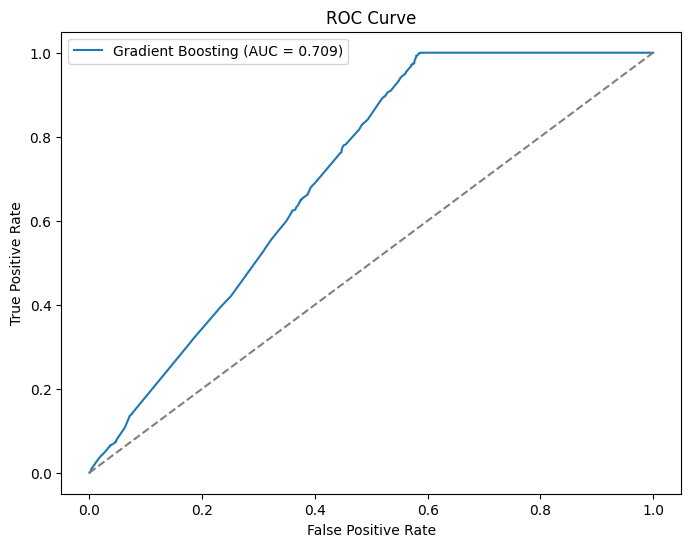

In [78]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Gradient Boosting (AUC = {roc_auc_score(y_test, y_prob):.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

<h4>Feature Importance</h4>

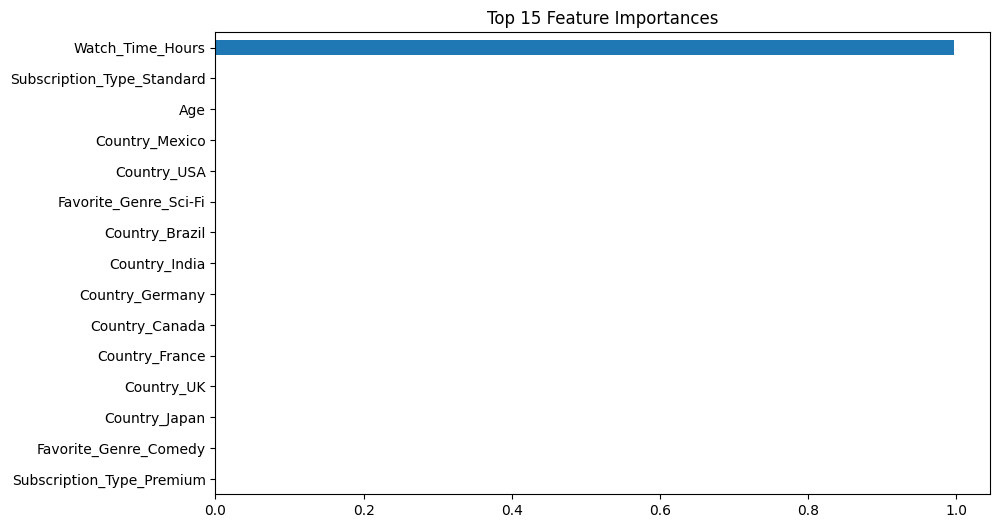

In [79]:
importance = best_gb.feature_importances_
feature_importance = pd.Series(importance, index=X_train.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importance.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances")
plt.show()

<p>Based on the analysis of multiple classification models for churn prediction:<br>
    <b>1. Best Model:</b> Gradient Boosting Classifier with optimized parameters: {'learning_rate': 0.01, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100, 'subsample': 1.0}<br>
    <b>2. Performance Metrics on Test data:</b> Accuracy=0.724, Precision(churned)=0.66, Recall(churned)=1.00, F1 Score=0.79, ROC-AUC=0.7086<br>
     The Gradient Boosting model effectively identifies all churned users (Recall = 1.0), making it highly suitable for proactive retention strategies. While some non-churned users are incorrectly flagged (Precision = 0.66), this trade-off is acceptable given the business impact. Key features influencing churn can be analyzed for actionable insights. It is recommended to deploy the model to predict churn probabilities for active users, prioritize retention efforts on high-risk users, and consider testing LightGBM, CatBoost, or XGBoost to potentially improve ROC-AUC and precision.
</p>

<h2>Save the Model</h2>

In [80]:
import joblib

joblib.dump(best_gb, "gradient_boosting_churn_model.pkl")

print("Model saved successfully!")

Model saved successfully!
